## import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings("ignore")

## load the dataset

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

The dataset contains 10000 rows and 14 colums.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


There are no missing value in the dataset and all data types looks perfect.

**Checking duplicates present or not**

In [7]:
df.duplicated().sum()

np.int64(0)

No duplicate value present in the dataset.

In the opininon, (RowNumber,CustomerId,Surname) columns are not important in predicting churn. They can confused model from learning pattern also can misclassified the prediction. So I will drop these columns.

In [8]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace = True)

In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


## Target feature is Exited. Let's see the dataset is balanced or not.

In [11]:
df['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

Here, I can clearly see that 0 class contains 79.63% data and 1 class contains 20.37 of data. So, The dataset is imbalanced.*For more clearly understand let's make a countplot .

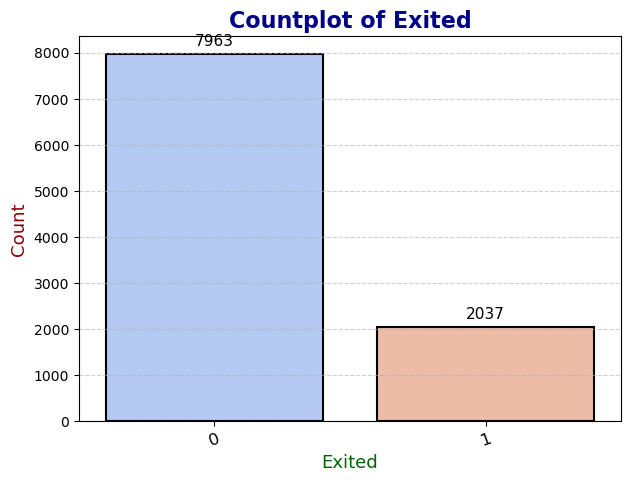

In [12]:
plt.figure(figsize=(7,5))
ax = sns.countplot(
    x=df['Exited'], 
    data=df, 
    palette="coolwarm",   # eye-catching color palette
    edgecolor="black",    # bar border
    linewidth=1.5
)

# Title & labels with styling
plt.title("Countplot of Exited", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Exited", fontsize=13, color="darkgreen")
plt.ylabel("Count", fontsize=13, color="darkred")

for container in ax.containers:
    ax.bar_label(container, fontsize=11, color="black", padding=4)

# Rotate x labels if needed
plt.xticks(rotation=20, fontsize=12)

# Add subtle grid
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [13]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [14]:
# Gender
df['Gender'].value_counts(normalize=True)*100

Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64

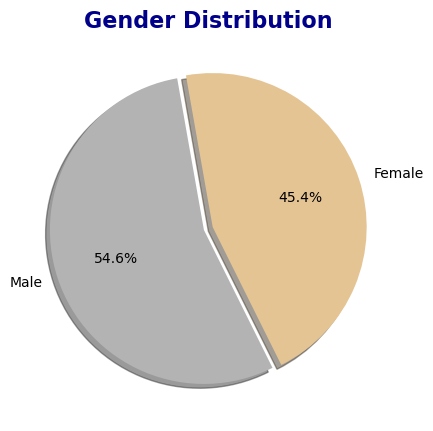

In [15]:
# Pie chart for gender
# Gender counts in percentage
gender_counts = df['Gender'].value_counts(normalize=True) * 100

# Pie chart
plt.figure(figsize=(5,5))
plt.pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%',        # percentage format
    startangle=100,           # rotation for better view
    colors=plt.cm.Set2_r(range(len(gender_counts))),  # attractive viridis palette
    explode=[0.03]*len(gender_counts),   # slight separation for each slice
    shadow=True               # add shadow effect
)

plt.title("Gender Distribution", fontsize=16, fontweight="bold", color="darkblue")
plt.show()

In the dataset, 54.57% Male and 45.43 % Female. So , the gender column is perfectly balanced .

In [16]:
df.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6474,695,France,Male,37,2,0.00,2,1,1,99692.65,0
6585,625,France,Male,39,5,0.00,1,1,0,99800.87,0
8141,486,Spain,Male,24,1,0.00,1,1,0,98802.76,0
4743,511,Spain,Female,57,8,122950.31,1,1,1,181258.76,0
2250,706,Spain,Male,20,8,0.00,2,1,1,12368.11,0


In [17]:
# Geography
df['Geography'].value_counts(normalize=True)*100

Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

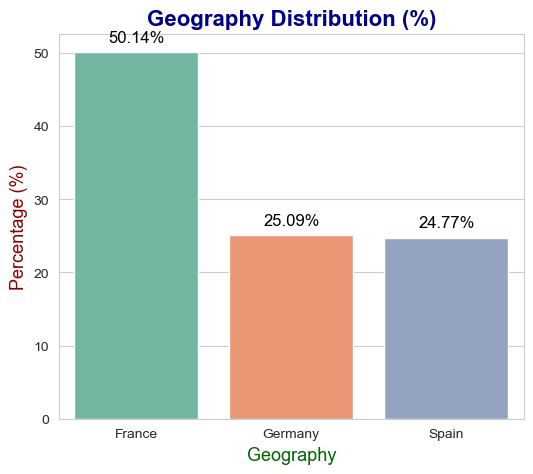

In [18]:
# Value counts in percentage
geo_counts = df['Geography'].value_counts(normalize=True) * 100

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(6,5))

# Bar Chart
palette = sns.color_palette("Set2")
bars = sns.barplot(x=geo_counts.index, y=geo_counts.values, palette=palette)

# Add value labels on top of bars
for bar in bars.patches:
    bars.annotate(f"{bar.get_height():.2f}%", 
                  (bar.get_x() + bar.get_width()/2, bar.get_height()),
                  ha="center", va="bottom", fontsize=12, color="black", xytext=(0,5),
                  textcoords="offset points")

# Titles and labels
plt.title("Geography Distribution (%)", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Geography", fontsize=13, color="darkgreen")
plt.ylabel("Percentage (%)", fontsize=13, color="darkred")

plt.show()

From france there are more customer contains compare to the Germany and Spain.

In [19]:
# Count exited by gender
exit_counts = df[df['Exited'] == 1]['Gender'].value_counts()
print(exit_counts)


Gender
Female    1139
Male       898
Name: count, dtype: int64


It is clearly see that, the gender female churn from the bank more.

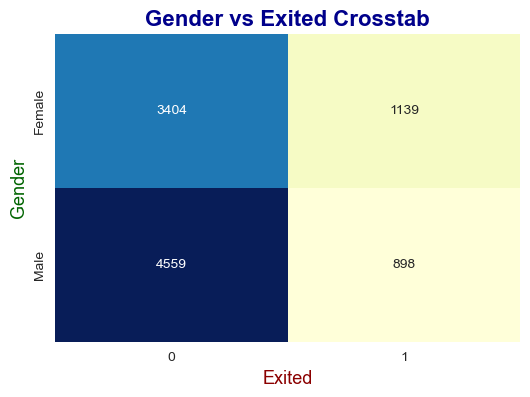

In [20]:
# Crosstab for Gender vs Exited
exit_table = pd.crosstab(df['Gender'], df['Exited'])

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(exit_table, annot=True, fmt="d", cmap="YlGnBu", cbar=False)

plt.title("Gender vs Exited Crosstab", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Exited", fontsize=13, color="darkred")
plt.ylabel("Gender", fontsize=13, color="darkgreen")
plt.show()


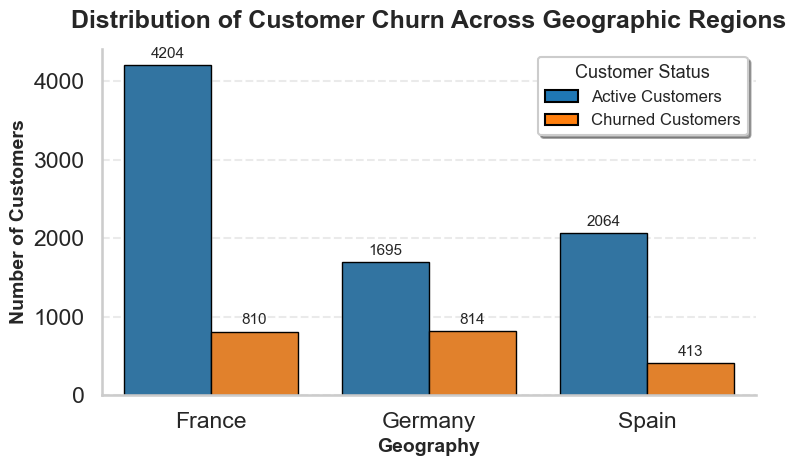

In [21]:
import matplotlib.patches as mpatches

# Crosstab
geo_exit = pd.crosstab(df['Geography'], df['Exited'])

# Long format
geo_exit_long = geo_exit.reset_index().melt(id_vars='Geography',var_name='Exited', value_name='Count')

# Theme
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(8, 5))

# Premium soft palette
palette = {0: "#1f77b4",   # Active Customers (Blue)
1: "#ff7f0e"    # Churned Customers (Orange)
}

# Bar plot
ax = sns.barplot(data=geo_exit_long,x="Geography", y="Count",hue="Exited", palette=palette, edgecolor="black", linewidth=1)

# Value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11, padding=3)

# Custom legend (FIXED)
legend_elements = [
    mpatches.Patch(facecolor="#1f77b4", edgecolor="black", label="Active Customers"),
    mpatches.Patch(facecolor="#ff7f0e", edgecolor="black", label="Churned Customers")
]

plt.legend( handles=legend_elements,title="Customer Status",fontsize=12,title_fontsize=13, frameon=True,fancybox=True,shadow=True,loc="upper right")

# Titles
plt.title("Distribution of Customer Churn Across Geographic Regions",fontsize=18, fontweight="bold",pad=15)

plt.xlabel("Geography", fontsize=14, fontweight="bold")
plt.ylabel("Number of Customers", fontsize=14, fontweight="bold")

# Grid styling
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', visible=False)

sns.despine()
plt.tight_layout()
plt.show()

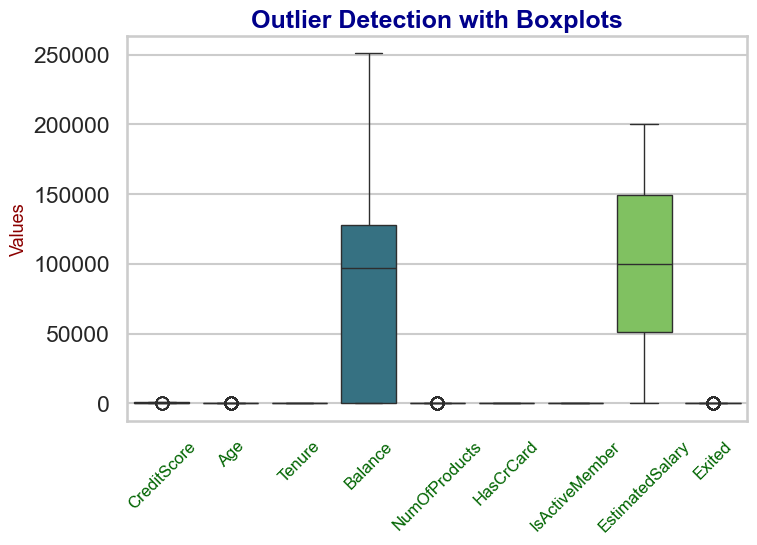

In [22]:
# Numeric columns
num_cols = df.select_dtypes(include=['float64','int64']).columns

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

# Attractive boxplot
sns.boxplot(data=df[num_cols], palette="viridis")

# Titles and labels
plt.title("Outlier Detection with Boxplots", fontsize=18, fontweight="bold", color="darkblue")
plt.xticks(rotation=45, fontsize=12, color="darkgreen")
plt.ylabel("Values", fontsize=13, color="darkred")

plt.show()



There are not outliers

In [23]:
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

In [24]:
numeric_cols

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

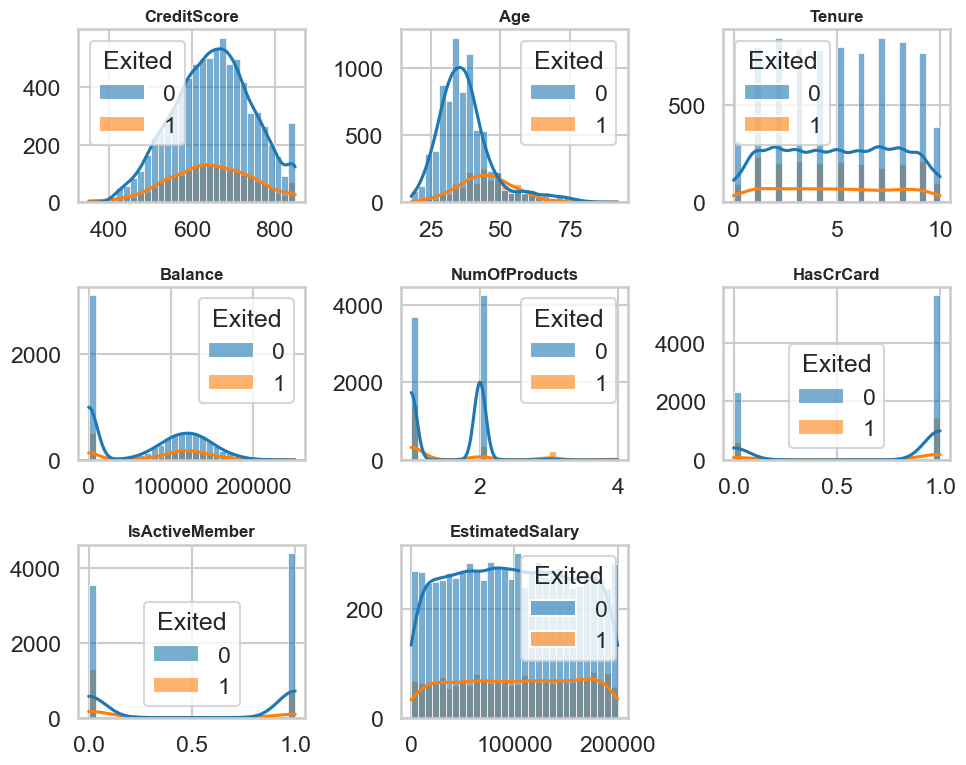

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary'
]

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    
    sns.histplot(
        data=df,
        x=col,
        hue="Exited",
        bins=30,
        kde=True,
        palette={0: "#1f77b4", 1: "#ff7f0e"},
        alpha=0.6
    )
    
    plt.title(col, fontsize=12, fontweight="bold")
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

The numeric columns looks normally distributed . So, model can learn pattern perfectly.

##  Encdoing 

In [26]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True,dtype=int)

In [27]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


## Separate X and y

In [28]:
X = df.drop('Exited',axis = 1)
y = df['Exited']
y.to_frame()

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [29]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


## Train_test_split

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"X_train shape : {X_train.shape} X_test shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape} y_test shape : {y_test.shape}")

X_train shape : (8000, 11) X_test shape : (2000, 11)
y_train shape : (8000,) y_test shape : (2000,)
